In [242]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings ; warnings.filterwarnings('ignore')

In [243]:
cust = pd.read_csv(r"C:\Users\CHARANJEET\OneDrive\Desktop\Documents\Case Study 1 - Retail Case Study\Customer.csv")
prod_cat = pd.read_csv(r"C:\Users\CHARANJEET\OneDrive\Desktop\Documents\Case Study 1 - Retail Case Study\prod_cat_info.csv")
trans = pd.read_csv(r"C:\Users\CHARANJEET\OneDrive\Desktop\Documents\Case Study 1 - Retail Case Study\Transactions.csv")

In [3]:
cust.head()

,customer_Id,DOB,Gender,city_code
0,268408,02-01-1970,M,4.0
1,269696,07-01-1970,F,8.0
2,268159,08-01-1970,F,8.0
3,270181,10-01-1970,F,2.0
4,268073,11-01-1970,M,1.0


In [88]:
prod_cat.head()

,prod_cat_code,prod_cat,prod_sub_cat_code,prod_subcat
0,1,Clothing,4,Mens
1,1,Clothing,1,Women
2,1,Clothing,3,Kids
3,2,Footwear,1,Mens
4,2,Footwear,3,Women


In [57]:
trans.head(5)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop


In [244]:
cust_final_0 = pd.merge(left = trans,right = cust,how = 'inner',left_on ='cust_id',right_on = 'customer_Id')
cust_final_0.head()

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,270351,26-09-1981,M,5.0
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,270384,11-05-1973,F,8.0
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,273420,27-07-1992,M,8.0
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop,271509,08-06-1981,M,3.0
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,273420,27-07-1992,M,8.0


In [245]:
cust_final = pd.merge(left = cust_final_0,right = prod_cat,left_on=['prod_cat_code','prod_subcat_code'],right_on = ['prod_cat_code','prod_sub_cat_code']
                      ,how = 'inner')
cust_final = cust_final.loc[ : :,['customer_Id','DOB','Gender','city_code','transaction_id','tran_date','prod_subcat_code','prod_cat_code','Qty','Rate','Tax','total_amt','Store_type','prod_cat','prod_subcat']]
cust_final

,customer_Id,DOB,Gender,city_code,transaction_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,prod_cat,prod_subcat
0,270351,26-09-1981,M,5.0,80712190438,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,Clothing,Women
1,270384,11-05-1973,F,8.0,29258453508,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,Electronics,Computers
2,273420,27-07-1992,M,8.0,51750724947,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,Books,DIY
3,271509,08-06-1981,M,3.0,93274880719,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop,Home and kitchen,Bath
4,273420,27-07-1992,M,8.0,51750724947,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,Books,DIY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23048,274550,21-02-1972,M,7.0,94340757522,25-01-2011,12,5,1,1264,132.720,1396.720,e-Shop,Books,Academic
23049,270022,27-04-1984,M,9.0,89780862956,25-01-2011,4,1,1,677,71.085,748.085,e-Shop,Clothing,Mens
23050,271020,20-06-1976,M,8.0,85115299378,25-01-2011,2,6,4,1052,441.840,4649.840,MBR,Home and kitchen,Furnishing
23051,270911,22-05-1970,M,2.0,72870271171,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop,Books,Children


In [246]:
cust_final.dtypes

customer_Id           int64
DOB                  object
Gender               object
city_code           float64
transaction_id        int64
tran_date            object
prod_subcat_code      int64
prod_cat_code         int64
Qty                   int64
Rate                  int64
Tax                 float64
total_amt           float64
Store_type           object
prod_cat             object
prod_subcat          object
dtype: object

In [247]:
cust_final.head(10)

,customer_Id,DOB,Gender,city_code,transaction_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,prod_cat,prod_subcat
0,270351,26-09-1981,M,5.0,80712190438,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,Clothing,Women
1,270384,11-05-1973,F,8.0,29258453508,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,Electronics,Computers
2,273420,27-07-1992,M,8.0,51750724947,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,Books,DIY
3,271509,08-06-1981,M,3.0,93274880719,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop,Home and kitchen,Bath
4,273420,27-07-1992,M,8.0,51750724947,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,Books,DIY
5,272357,09-10-1982,F,6.0,97439039119,23-02-2014,8,3,-2,-824,173.040,-1821.040,TeleShop,Electronics,Personal Appliances
6,273667,29-05-1981,M,9.0,45649838090,22-02-2014,11,6,-1,-1450,152.250,-1602.250,e-Shop,Home and kitchen,Bath
7,271489,21-04-1971,M,9.0,22643667930,22-02-2014,12,6,-1,-1225,128.625,-1353.625,TeleShop,Home and kitchen,Tools
8,275108,04-11-1971,F,8.0,79792372943,22-02-2014,3,1,-3,-908,286.020,-3010.020,MBR,Clothing,Kids
9,269014,27-11-1979,F,3.0,50076728598,21-02-2014,8,3,-4,-581,244.020,-2568.020,e-Shop,Electronics,Personal Appliances


In [123]:
cust_final.tail(10)

,customer_Id,DOB,Gender,city_code,transaction_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,prod_cat,prod_subcat
23043,271982,10-08-1976,M,8.0,49882891062,2011-01-25,10,5,4,1330,558.600,5878.600,e-Shop,Books,Non-Fiction
23044,273982,12-10-1991,M,4.0,14787475597,2011-01-25,4,3,5,969,508.725,5353.725,e-Shop,Electronics,Mobiles
23045,273031,17-01-1980,F,8.0,50691119572,2011-01-25,6,5,1,1148,120.540,1268.540,TeleShop,Books,DIY
23046,272049,28-06-1975,F,6.0,40893803228,2011-01-25,11,6,3,1077,339.255,3570.255,e-Shop,Home and kitchen,Bath
23047,266866,18-04-1974,M,4.0,30856003613,2011-01-25,4,2,2,444,93.240,981.240,TeleShop,Footwear,Kids
23048,274550,21-02-1972,M,7.0,94340757522,2011-01-25,12,5,1,1264,132.720,1396.720,e-Shop,Books,Academic
23049,270022,27-04-1984,M,9.0,89780862956,2011-01-25,4,1,1,677,71.085,748.085,e-Shop,Clothing,Mens
23050,271020,20-06-1976,M,8.0,85115299378,2011-01-25,2,6,4,1052,441.840,4649.840,MBR,Home and kitchen,Furnishing
23051,270911,22-05-1970,M,2.0,72870271171,2011-01-25,11,5,3,1142,359.730,3785.730,TeleShop,Books,Children
23052,271961,15-01-1982,M,1.0,77960931771,2011-01-25,11,5,1,447,46.935,493.935,TeleShop,Books,Children


In [248]:
five_point_summ =cust_final.describe().T.loc[ : : ,'min':'max']
five_point_summ

,min,25%,50%,75%,max
customer_Id,266783.000,2.689350e+05,2.709800e+05,2.731140e+05,2.752650e+05
city_code,1.000,3.000000e+00,5.000000e+00,8.000000e+00,1.000000e+01
transaction_id,3268991.000,2.493864e+10,5.009313e+10,7.533000e+10,9.998755e+10
prod_subcat_code,1.000,3.000000e+00,5.000000e+00,1.000000e+01,1.200000e+01
prod_cat_code,1.000,2.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Qty,-5.000,1.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00
Rate,-1499.000,3.120000e+02,7.100000e+02,1.109000e+03,1.500000e+03
Tax,7.350,9.828000e+01,1.990800e+02,3.657150e+02,7.875000e+02
total_amt,-8270.925,7.624500e+02,1.754740e+03,3.569150e+03,8.287500e+03


In [250]:
customer_final_object = cust_final.select_dtypes(include='object')
customer_final_numeric = cust_final.select_dtypes(include=['int64','float64']) 

In [252]:
customer_final_object.columns

Index(['DOB', 'Gender', 'tran_date', 'Store_type', 'prod_cat', 'prod_subcat'], dtype='object')

In [254]:
customer_final_numeric.columns

Index(['customer_Id', 'city_code', 'transaction_id', 'prod_subcat_code',
       'prod_cat_code', 'Qty', 'Rate', 'Tax', 'total_amt'],
      dtype='object')

In [258]:
## Frequency Table for all categorical variable
for cols in customer_final_object:
    print(f"\n frequency tbl for:",cols)
    print(cust_final[cols].value_counts())


 frequency tbl for: DOB
DOB
27-12-1988    32
17-09-1982    32
25-02-1974    27
20-03-1972    25
18-11-1991    24
              ..
29-01-1976     1
01-05-1980     1
23-06-1988     1
25-06-1985     1
10-06-1972     1
Name: count, Length: 3987, dtype: int64

 frequency tbl for: Gender
Gender
M    11811
F    11233
Name: count, dtype: int64

 frequency tbl for: tran_date
tran_date
13-07-2011    35
21-12-2013    33
23-10-2011    33
22-11-2011    33
25-09-2011    33
              ..
23-02-2014     2
24-02-2014     2
27-02-2014     1
21-02-2014     1
28-02-2014     1
Name: count, Length: 1129, dtype: int64

 frequency tbl for: Store_type
Store_type
e-Shop            9311
MBR               4661
Flagship store    4577
TeleShop          4504
Name: count, dtype: int64

 frequency tbl for: prod_cat
prod_cat
Books               6069
Electronics         4898
Home and kitchen    4129
Footwear            2999
Clothing            2960
Bags                1998
Name: count, dtype: int64

 frequency tbl f

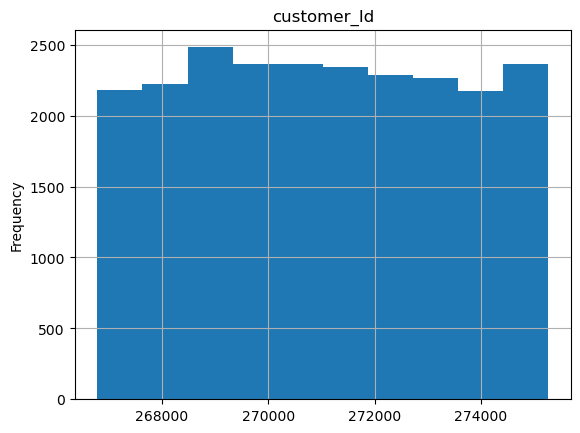

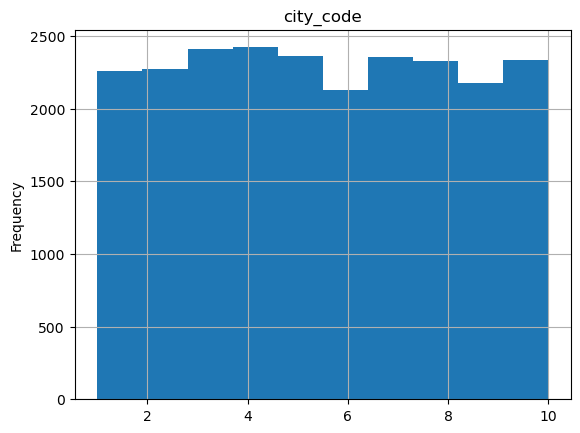

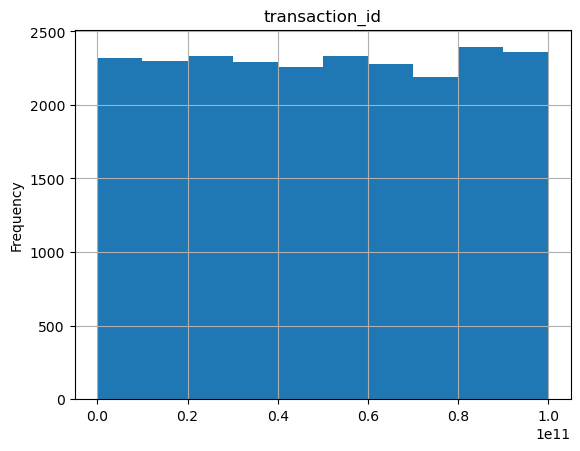

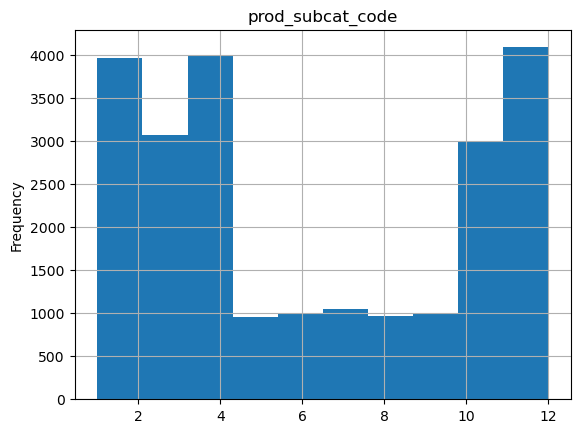

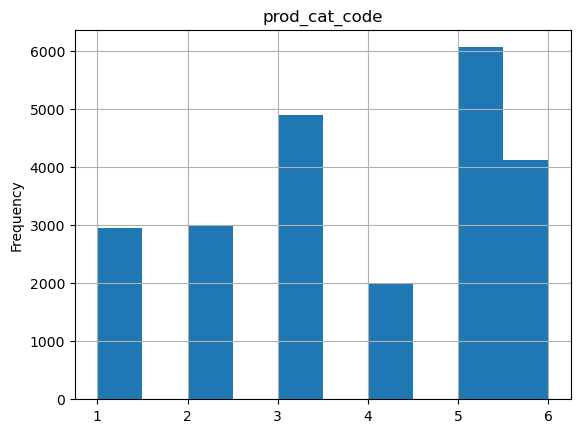

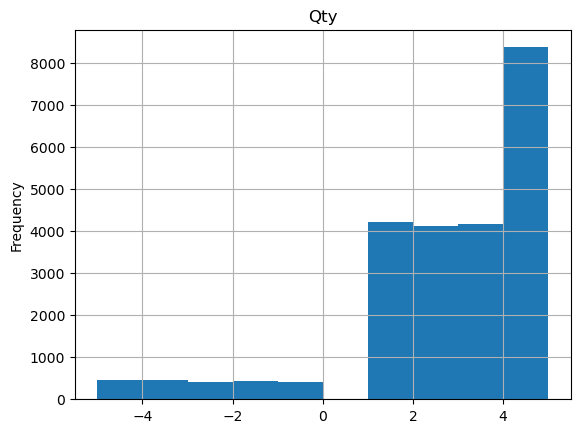

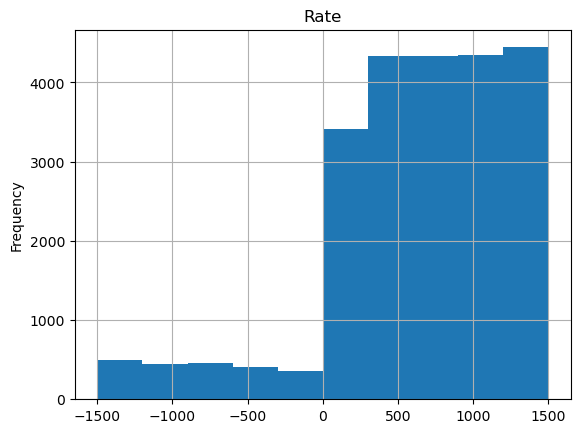

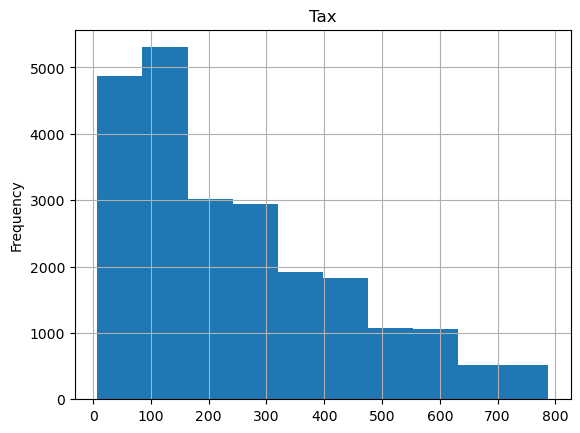

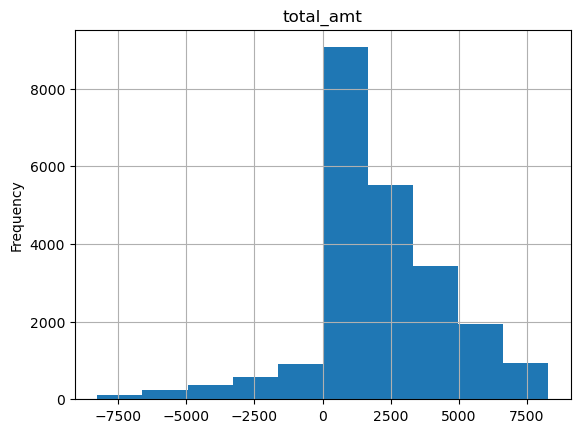

In [284]:
# 3. Generate histograms for all continuous variables and frequency bars for categorical variables.
for col in customer_final_numeric:
    cust_final[col].plot(kind = 'hist')
    plt.grid()
    plt.title(col)
    plt.show()

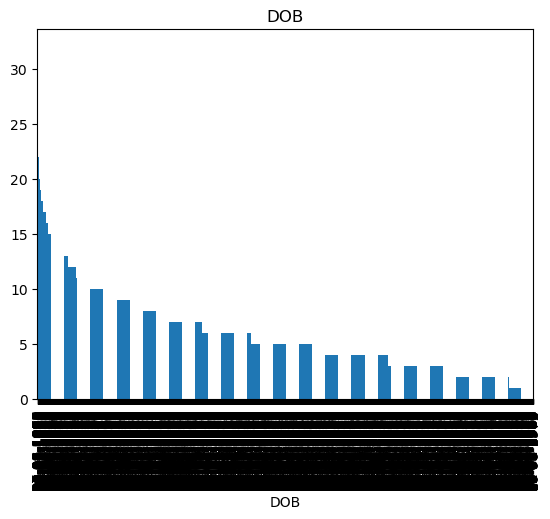

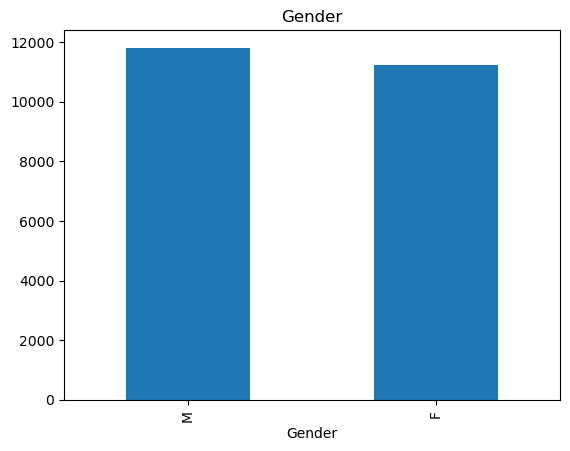

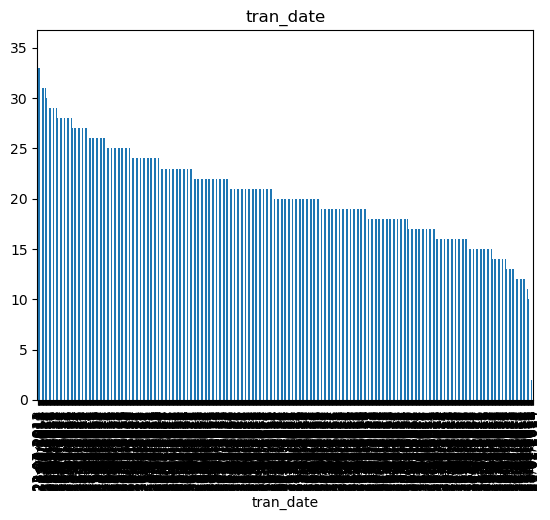

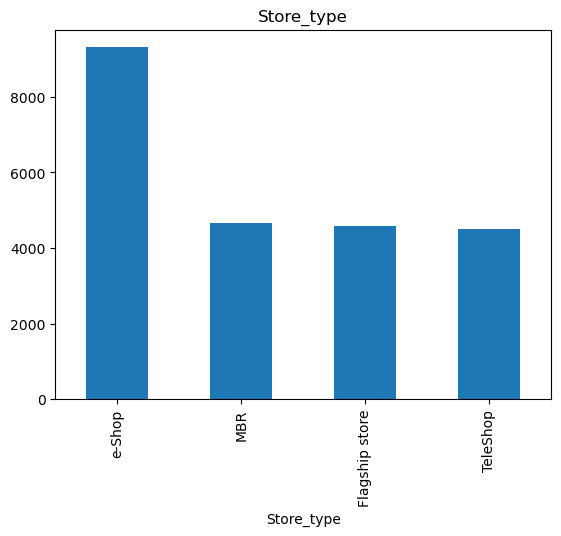

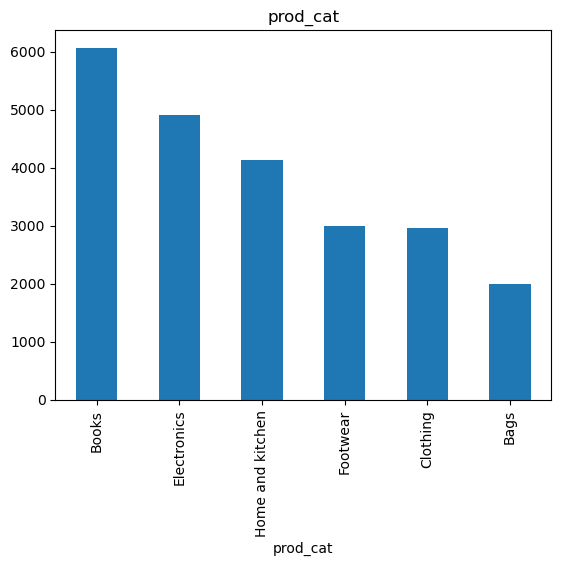

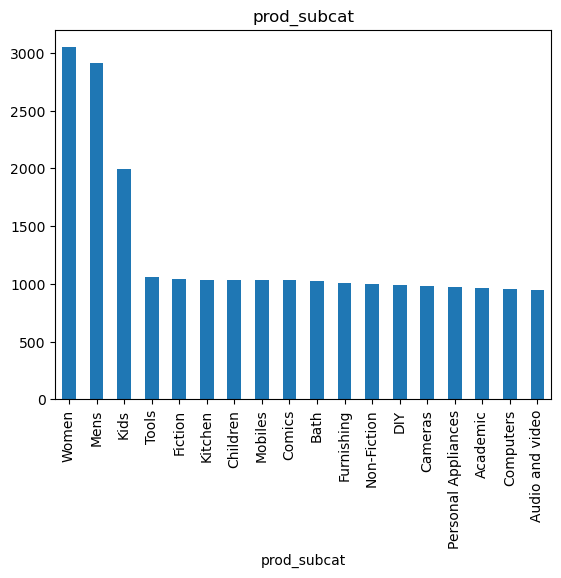

In [263]:
for col in customer_final_object:
    cust_final[col].value_counts().plot(kind = 'bar')
    plt.title(col)
    plt.show()

#### a. Time period of the available transaction data
#### b. Count of transactions where the total amount of transaction was negative

In [285]:
cust_final.tran_date = pd.to_datetime(cust_final.tran_date,format = '%d-%m-%Y',errors = 'coerce')

In [153]:
td = max(cust_final.tran_date) - min(cust_final.tran_date)
print("Time Range in days:",td.days)

Time Range in days: 1130


In [269]:
neg_tran = len(cust_final[cust_final.total_amt < 0])
print("Count of trans where total amt is negative:",neg_tran)

Count of trans where total amt is negative: 2177


In [154]:
cust_final.drop_duplicates(subset ='transaction_id')

,customer_Id,DOB,Gender,city_code,transaction_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,prod_cat,prod_subcat
0,270351,26-09-1981,M,5.0,80712190438,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,Clothing,Women
1,270384,11-05-1973,F,8.0,29258453508,2014-02-27,5,3,-5,-1497,785.925,-8270.925,e-Shop,Electronics,Computers
2,273420,27-07-1992,M,8.0,51750724947,2014-02-24,6,5,-2,-791,166.110,-1748.110,TeleShop,Books,DIY
3,271509,08-06-1981,M,3.0,93274880719,2014-02-24,11,6,-3,-1363,429.345,-4518.345,e-Shop,Home and kitchen,Bath
5,272357,09-10-1982,F,6.0,97439039119,2014-02-23,8,3,-2,-824,173.040,-1821.040,TeleShop,Electronics,Personal Appliances
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23047,266866,18-04-1974,M,4.0,30856003613,2011-01-25,4,2,2,444,93.240,981.240,TeleShop,Footwear,Kids
23048,274550,21-02-1972,M,7.0,94340757522,2011-01-25,12,5,1,1264,132.720,1396.720,e-Shop,Books,Academic
23049,270022,27-04-1984,M,9.0,89780862956,2011-01-25,4,1,1,677,71.085,748.085,e-Shop,Clothing,Mens
23050,271020,20-06-1976,M,8.0,85115299378,2011-01-25,2,6,4,1052,441.840,4649.840,MBR,Home and kitchen,Furnishing


##### 5. Analyze which product categories are more popular among females vs male customers.

In [156]:
cust_final.pivot_table(index = 'prod_cat',columns = 'Gender',values ='transaction_id',aggfunc = 'count')

Gender,F,M
prod_cat,,
Bags,994,1004
Books,2949,3116
Clothing,1439,1518
Electronics,2328,2570
Footwear,1529,1469
Home and kitchen,1994,2134


##### 6. Which City code has the maximum customers and what was the percentage of customers from that city.

In [183]:
df = cust.pivot_table(index ='city_code',values = 'customer_Id',aggfunc = 'count').reset_index()
df = df.max()
print("City with max customers and the number:\n",df)

City with max customers and the number:
 city_code       10.0
customer_Id    595.0
dtype: float64


In [191]:
percentage = df.customer_Id/cust.customer_Id.shape[0]*100
print(f"Percentage of city with max customers is {percentage} ")

Percentage of city with max customers is 10.53656808925093 


#### 7.Which store type sells the maximum products by value and by quantity

In [206]:
df_1 =cust_final.pivot_table(index = 'prod_cat',values = ['total_amt','Qty'],aggfunc='sum').reset_index()
print("Storetype which sells maximum prod by sales and quantity:\n",df_1.max() )

Storetype which sells maximum prod by sales and quantity:
 prod_cat     Home and kitchen
Qty                     14669
total_amt         12822694.04
dtype: object


#### 8. What was the total amount earned from the "Electronics" and "Clothing" categories from Flagship Stores


In [211]:
df_2 = cust_final[cust_final['prod_cat'].isin(['Electronics','Clothing']) & (cust_final['Store_type']== 'Flagship store') ]
df_2.groupby('prod_cat')['total_amt'].sum()

prod_cat
Clothing       1194423.23
Electronics    2215136.04
Name: total_amt, dtype: float64

#### 9. What was the total amount earned from "Male" customers under the "Electronics" category

In [217]:
df_3 = cust_final[(cust_final['Gender'] == 'M') & (cust_final['prod_cat'] == 'Electronics') ]
df_3.groupby('prod_cat')['total_amt'].sum()

prod_cat
Electronics    5703109.425
Name: total_amt, dtype: float64

#### 10. How many customers have more than 10 unique transactions, after removing all transactions which have any negative amounts?

In [282]:
positive_tran = cust_final[cust_final.total_amt > 0]
df_4 = positive_tran.groupby('customer_Id')['transaction_id'].nunique()
df_4[df_4 > 10].count()

6

#### 11. For all customers aged between 25 - 35, find out:
##### a. What was the total amount spent for “Electronics” and “Books” product categories?
##### b. What was the total amount spent by these customers between 1st Jan, 2014 to 1st Mar, 2014

In [276]:
cust_final['DOB'] = pd.to_datetime(cust_final['DOB'])
cust_final['Age'] = pd.Timestamp.now().year - cust_final['DOB'].dt.year

In [277]:
age_df = cust_final[(cust_final['Age'] >=25)&(cust_final['Age'] <=35) ]

In [278]:
#a)
age_df[ age_df['prod_cat'].isin(['Electronics','Books'])].groupby('prod_cat')['total_amt'].sum()

prod_cat
Books          1095237.325
Electronics     843632.140
Name: total_amt, dtype: float64

In [279]:
#b)
age_df[(age_df['tran_date'] >= '2014-01-01') & (age_df['tran_date'] <= '2014-03-01')]['total_amt'].sum()

117951.01499999998